Develop a machine learning model to classify music tracks into different genres (rock vs. hip-hop) using audio features extracted from the tracks [ https://github.com/shukkkur/Classify-Song-Genres-from-Audio-Data].

## Overview
With the growth of digital music platforms like Spotify and Apple Music, automatically identifying the genre of a song has become very important. Genre classification helps improve music recommendations, organize large music libraries, and support streaming algorithms. However, songs from different genres often share similar rhythms, instruments, or patterns, which makes genre classification a difficult task.

## Project Goal
This project focuses on building a system that can automatically classify songs into different genres using audio features and deep learning models. We'll extract key information from music files—such as frequency and rhythm patterns—and use this data to train a model that can recognize different genres accurately.

We are using the preprocessed GTZAN dataset, specifically the `features_3_sec.csv` file from Kaggle (https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/data). This dataset contains audio features extracted from 3-second segments of the original audio files. Since this data is preprocessed, including normalization, we will not be performing additional normalization steps in this notebook.

The original GTZAN dataset, from which the `features_3_sec.csv` was derived, has the following characteristics:

- **Total Tracks:** 1000 audio files
- **Duration:** Each file is 30 seconds long
- **Format:** All tracks are in .wav format
- **Genres:** 10 different genres, each with 100 samples:
  - Blues
  - Classical
  - Country
  - Disco
  - Hip-hop
  - Jazz
  - Metal
  - Pop
  - Reggae
  - Rock

## Approach
We will follow these main steps in the project:

- **Feature Extraction**: The `features_3_sec.csv` file already contains the extracted features, so we will be loading and utilizing these pre-computed features. These include:
  - MFCCs (Mel-Frequency Cepstral Coefficients)
  - Mel Spectrograms
  - Chroma Features
  - Spectral Centroid, Bandwidth, and Zero-Crossing Rate
- **Model Development**: We will use the extracted features to train machine learning models for genre classification. XGBoost (Extreme Gradient Boosting) and Random Forest are powerful algorithms we will utilize.
- **Evaluation**: We'll evaluate the model using metrics like accuracy, confusion matrix, precision, and F1-score to assess its performance in classifying between 'rock' and 'hiphop' genres.

## Expected Outcome

The final models should be able to accurately predict whether an unseen music file belongs to the 'rock' or 'hiphop' genre based on its audio features. This can be a valuable tool for streaming services, music libraries, and mobile music apps to organize and recommend content more effectively for these specific genres.

In [ ]:
!pip install librosa matplotlib

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.utils import to_categorical
from xgboost import XGBClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import learning_curve
from IPython.display import Audio, display
from sklearn.decomposition import PCA
import pathlib
#from google.colab import drive



2025-09-14 11:19:14.107736: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-14 11:19:14.142802: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-14 11:19:15.137669: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-14 11:19:17.275081: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [ ]:
# Loop through each genre folder, print the genre name, and count the number of audio files in that genre.
for genre in all_genres:
    print(f"Genre: {genre}")
    genre_path = os.path.join(dataset_path, genre)
    files = os.listdir(genre_path)
    print(f"Number of files: {len(files)}")


Genre: hiphop
Number of files: 100
Genre: metal
Number of files: 100
Genre: classical
Number of files: 100
Genre: jazz
Number of files: 100
Genre: reggae
Number of files: 100
Genre: rock
Number of files: 100
Genre: country
Number of files: 100
Genre: pop
Number of files: 100
Genre: blues
Number of files: 100
Genre: disco
Number of files: 100


In [ ]:
# List of genres to include
target_genres = ['rock', 'hiphop']

### Harmonic and Percussive Components Analysis

The **Harmonic–Percussive Source Separation (HPSS)** technique decomposes an audio signal into two layers:



- **Harmonic (Blue):** Sustained, tonal elements such as vocals, guitar chords, and string sections.
- **Percussive (Orange):** Rhythmic, transient elements like drum hits and sharp attacks.

By isolating these components, we gain insight into how each genre balances melodic/harmonic material versus rhythmic emphasis.

**Interpretation:**

- Genres like classical and jazz may emphasize smoother harmonic content (sustained notes, flowing chord progressions) with more subtle percussion.
- Large orange spikes indicate a strong rhythmic emphasis (e.g., heavy drum hits in hip-hop).
- Metal features strong percussive spikes (drums, aggressive attacks) layered with powerful harmonic elements (distorted guitars, sustained chords).

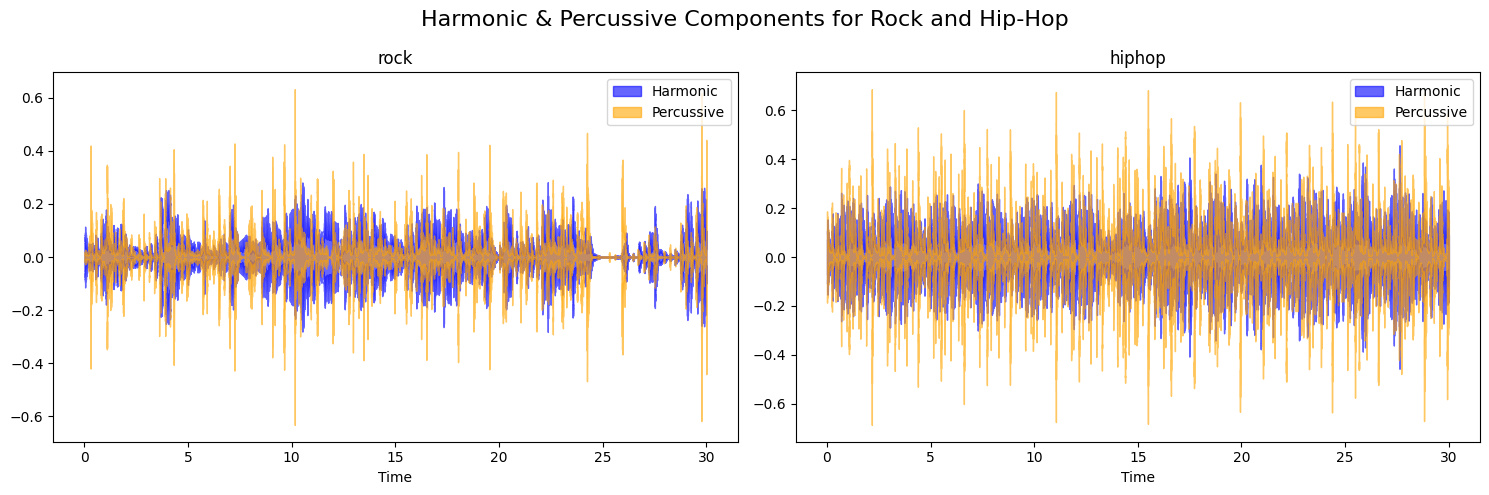

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Harmonic & Percussive Components for Rock and Hip-Hop', fontsize=16)
axs = axs.flatten()

for i, genre in enumerate(target_genres):
    genre_path = os.path.join(dataset_path, genre)
    file_path = os.path.join(genre_path, os.listdir(genre_path)[0])
    y, sr = librosa.load(file_path)

    y_harmonic, y_percussive = librosa.effects.hpss(y)
    librosa.display.waveshow(y_harmonic, sr=sr, ax=axs[i], color='blue', alpha=0.6, label='Harmonic')
    librosa.display.waveshow(y_percussive, sr=sr, ax=axs[i], color='orange', alpha=0.6, label='Percussive')

    axs[i].set_title(f'{genre}')
    axs[i].legend(loc='upper right')

plt.tight_layout()
plt.show()




### What Can We Learn from These Plots?

These plots reveal how different music genres balance melody and rhythm:

**Key Insights:**

- **Classical & Jazz:**
    - Smoother harmonic content (sustained notes, flowing chord progressions)
    - Subtle percussion elements

- **Hip-Hop:**
    - Large orange spikes indicate strong rhythmic emphasis (heavy drum hits)

- **Metal:**
    - Strong percussive spikes (drums, aggressive attacks)
    - Powerful harmonic elements (distorted guitars, sustained chords)

**Why This Matters:**

- Visualizing harmonic and percussive components helps us understand the unique audio characteristics of each genre.
- These differences are crucial for building accurate genre classification models.

By analyzing these plots, we can identify which features best separate genres and guide our feature engineering for machine learning.

### MFCC (Mel-Frequency Cepstral Coefficients) Analysis

MFCCs are a representation of the short-term power spectrum of a sound, based on a linear cosine transform of a log power spectrum on a nonlinear mel scale of frequency.

**How MFCCs Work:**

1. **Frame Division:** The audio signal is divided into short frames (typically 20-40 ms) to capture temporal changes.
2. **Frequency Domain Conversion:** Each frame is converted from the time domain to the frequency domain using the Fast Fourier Transform (FFT).
3. **Mel Scale Mapping:** The frequency spectrum is mapped to the mel scale, a nonlinear scale that approximates how humans perceive pitch. A set of triangular filters (mel filter bank) is applied to emphasize perceptually relevant frequencies.
4. **Logarithmic Compression:** The power spectrum is transformed using a logarithm to mimic the human ear's sensitivity to sound intensity.
5. **Discrete Cosine Transform (DCT):** DCT is applied to decorrelate the filter bank energies and produce a compact set of coefficients (the MFCCs).

MFCCs are widely used in audio and speech analysis because they capture the timbral and textural characteristics of sound in a way that aligns with human auditory perception.

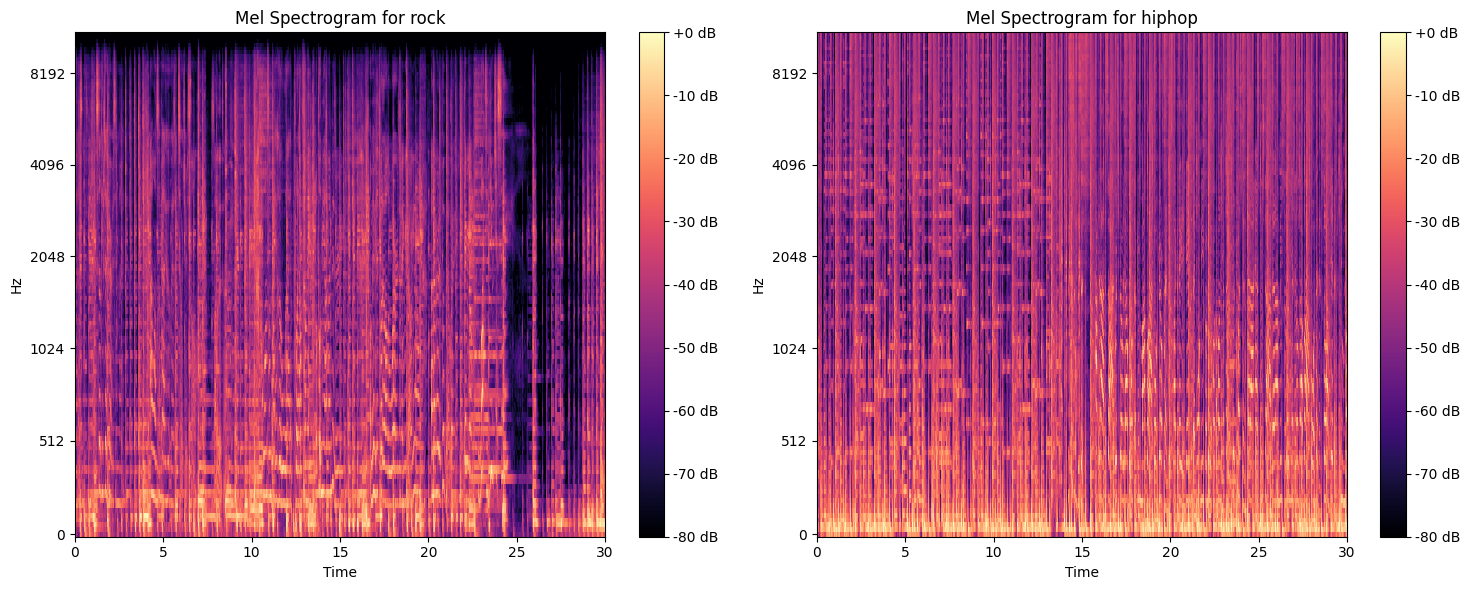

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
axs = axs.flatten()

for i, genre in enumerate(target_genres):
    genre_path = os.path.join(dataset_path, genre)
    file_path = os.path.join(genre_path, os.listdir(genre_path)[0])
    y, sr = librosa.load(file_path)

    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    librosa.display.specshow(mel_db, y_axis='mel', x_axis='time', ax=axs[i])
    plt.colorbar(axs[i].collections[0], ax=axs[i], format='%+2.0f dB')
    axs[i].set_title(f'Mel Spectrogram for {genre}')

plt.tight_layout()
plt.show()

### What Can We Learn from These Plots?

These MFCC plots help us understand the unique audio fingerprints of each genre:

**Key Observations:**

- **Rock & Metal:**
    - More pronounced high-frequency components
    - Sharp transitions and intense color changes indicate energetic sections

- **Classical & Jazz:**
    - Smoother transitions in color intensity
    - Dominance of lower and mid-frequency components

**Interpretation:**

- Each genre's MFCCs reflect its musical characteristics—rhythm, harmony, and timbre.
- Sudden changes in color intensity may indicate transitions between song sections (e.g., verse to chorus).

**Why This Matters:**

- These visual patterns help us identify similarities (e.g., blues and jazz) and differences (e.g., classical vs. metal) between genres.
- Understanding these distinctions guides feature selection and improves the accuracy of genre classification models.

### Mel Spectrogram Analysis

A **Mel Spectrogram** visually represents the frequency content of an audio signal over time, mapped to the Mel scale.

**Key Points:**

- The Mel scale approximates how the human ear perceives pitch, emphasizing lower frequencies where we are most sensitive.
- Mel spectrograms compress higher frequencies, making patterns in music more interpretable for both humans and machine learning models.

**Why Use Mel Spectrograms?**

- They highlight important musical features such as rhythm, harmony, and timbre.
- Useful for distinguishing genres, as each genre often has a unique spectrogram pattern.

**Interpretation:**

- Bright areas indicate strong energy at certain frequencies and times.
- Genre-specific patterns (e.g., steady rhythms in pop, complex harmonics in classical) can be visually identified.

Mel spectrograms are a powerful tool for both audio analysis and machine learning-based music genre classification.

### Genre Classification - XGBoost

**XGBoost** is a powerful ensemble learning algorithm based on decision trees. It is widely used for classification tasks due to its high accuracy, speed, and flexibility.

**Key Features of XGBoost:**

- Builds a series of decision trees sequentially, where each tree corrects errors made by the previous ones.
- Uses gradient boosting to optimize model performance.
- Handles structured and numeric data efficiently.
- Supports regularization to prevent overfitting.

**Why Use XGBoost for Genre Classification?**

- Our extracted audio features (MFCCs, spectral features, etc.) are numeric and well-suited for tree-based models.
- XGBoost can capture complex relationships between features and genres.
- Often outperforms other machine learning models in terms of accuracy and speed.

**Workflow:**

1. Prepare and scale audio features.
2. Train the XGBoost classifier on labeled data.
3. Evaluate model performance using metrics like accuracy, confusion matrix, and classification report.

XGBoost provides a robust foundation for building an accurate music genre classification system.

In [ ]:
# Features Loading
audio_features =pathlib.Path(r"Data/features_3_sec.csv/")
data = pd.read_csv(audio_features)
print(data.head())

# Filter for only hiphop and rock
data = data[data["label"].isin(["rock", "hiphop"])].reset_index(drop=True)
print("Filtered genres:", data["label"].unique())

# Features and Labels
X = data.drop(columns=["filename", "label"])
y = data["label"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


            filename  length  chroma_stft_mean  chroma_stft_var  rms_mean  \
0  blues.00000.0.wav   66149          0.335406         0.091048  0.130405   
1  blues.00000.1.wav   66149          0.343065         0.086147  0.112699   
2  blues.00000.2.wav   66149          0.346815         0.092243  0.132003   
3  blues.00000.3.wav   66149          0.363639         0.086856  0.132565   
4  blues.00000.4.wav   66149          0.335579         0.088129  0.143289   

    rms_var  spectral_centroid_mean  spectral_centroid_var  \
0  0.003521             1773.065032          167541.630869   
1  0.001450             1816.693777           90525.690866   
2  0.004620             1788.539719          111407.437613   
3  0.002448             1655.289045          111952.284517   
4  0.001701             1630.656199           79667.267654   

   spectral_bandwidth_mean  spectral_bandwidth_var  ...  mfcc16_var  \
0              1972.744388           117335.771563  ...   39.687145   
1              2010.05

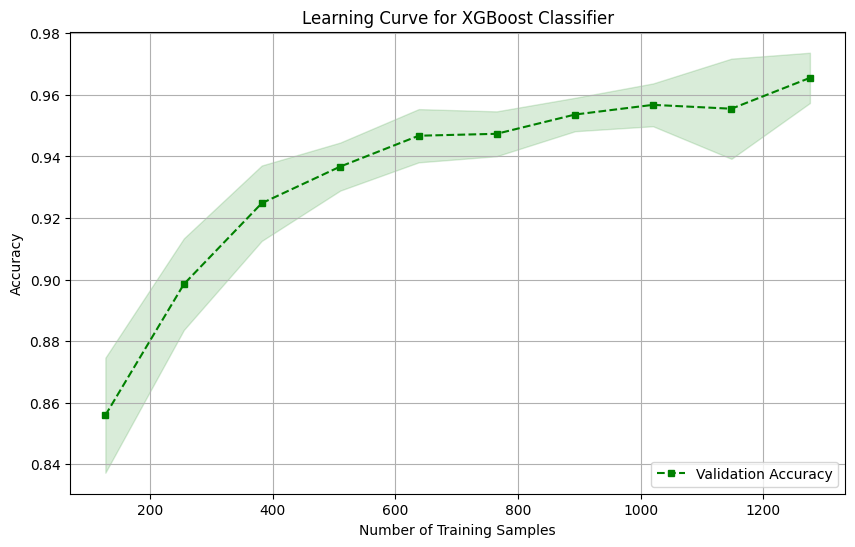


Accuracy: 96.50%

Classification Report:
              precision    recall  f1-score   support

      hiphop       0.95      0.97      0.96       193
        rock       0.98      0.96      0.97       207

    accuracy                           0.96       400
   macro avg       0.96      0.97      0.96       400
weighted avg       0.97      0.96      0.97       400



In [ ]:
# Train-Test Split and Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# XGBoost Model
xgb_model = XGBClassifier(eval_metric='logloss')
# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=xgb_model,
    X=X_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Mean & Standard Deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation Accuracy')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid()
plt.title('Learning Curve for XGBoost Classifier')
plt.show()

# Fit and evaluate model
xgb_model.fit(X_train_scaled, y_train)
y_pred = xgb_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

In [ ]:
# Save scaler and label encoder for UI
import joblib
joblib.dump(scaler, 'scaler.pkl')
print('Scaler saved as scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
print('LabelEncoder saved as label_encoder.pkl')

Scaler saved as scaler.pkl
LabelEncoder saved as label_encoder.pkl


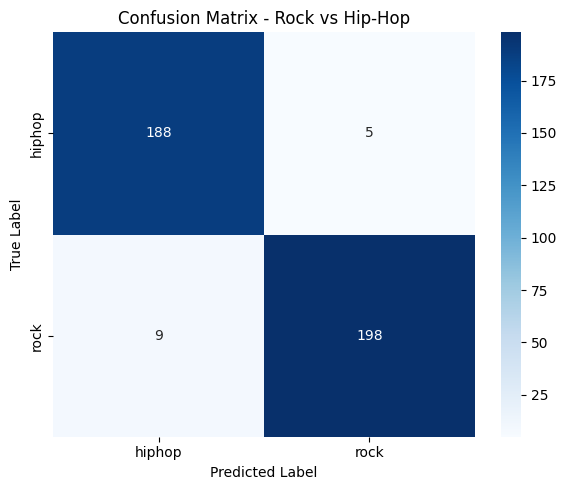

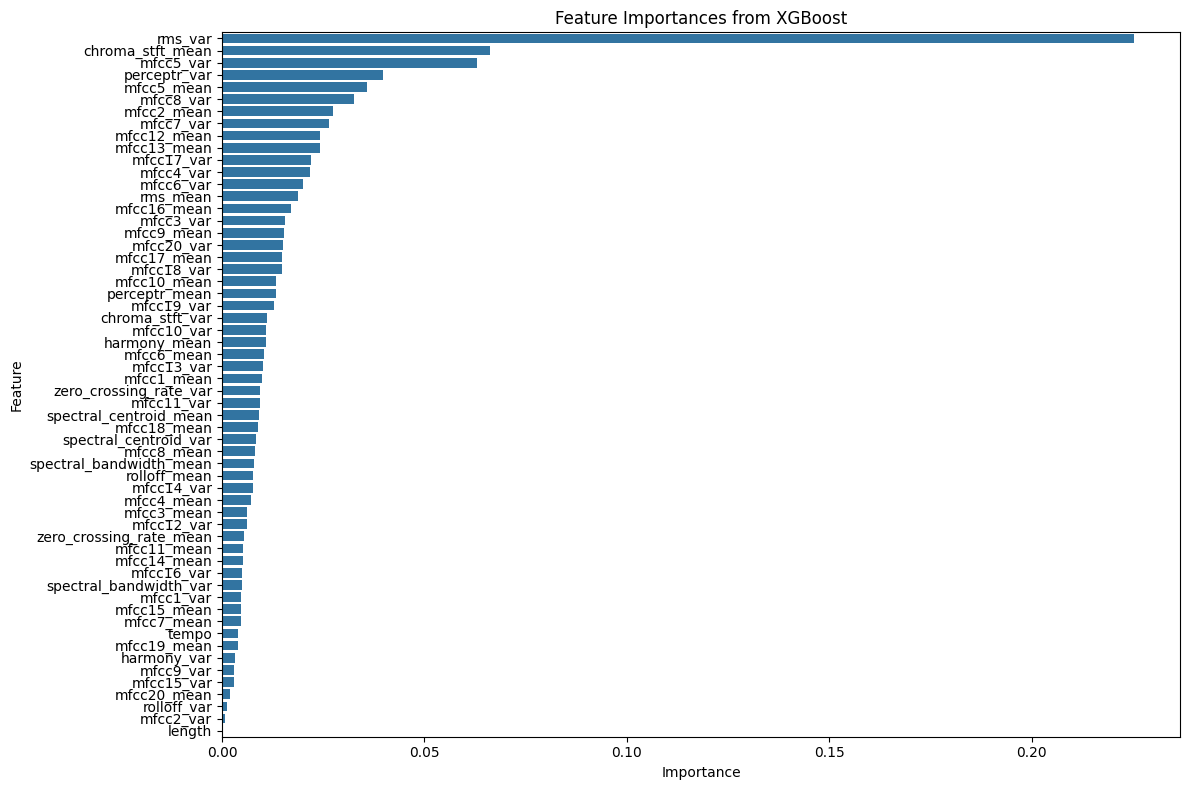

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Rock vs Hip-Hop")
plt.tight_layout()
plt.show()

# Feature Importances from the XGBoost
# Feature Importances from XGBoost
importances = xgb_model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=features[indices])
plt.title("Feature Importances from XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Random Forest Accuracy: 96.50%

Random Forest Classification Report:
              precision    recall  f1-score   support

      hiphop       0.96      0.97      0.96       193
        rock       0.97      0.96      0.97       207

    accuracy                           0.96       400
   macro avg       0.96      0.97      0.96       400
weighted avg       0.97      0.96      0.97       400



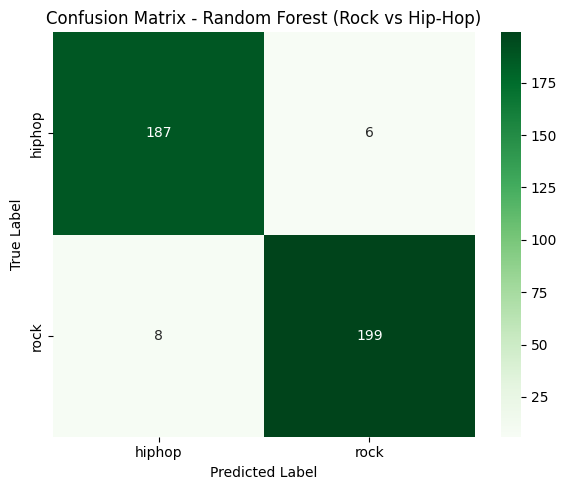

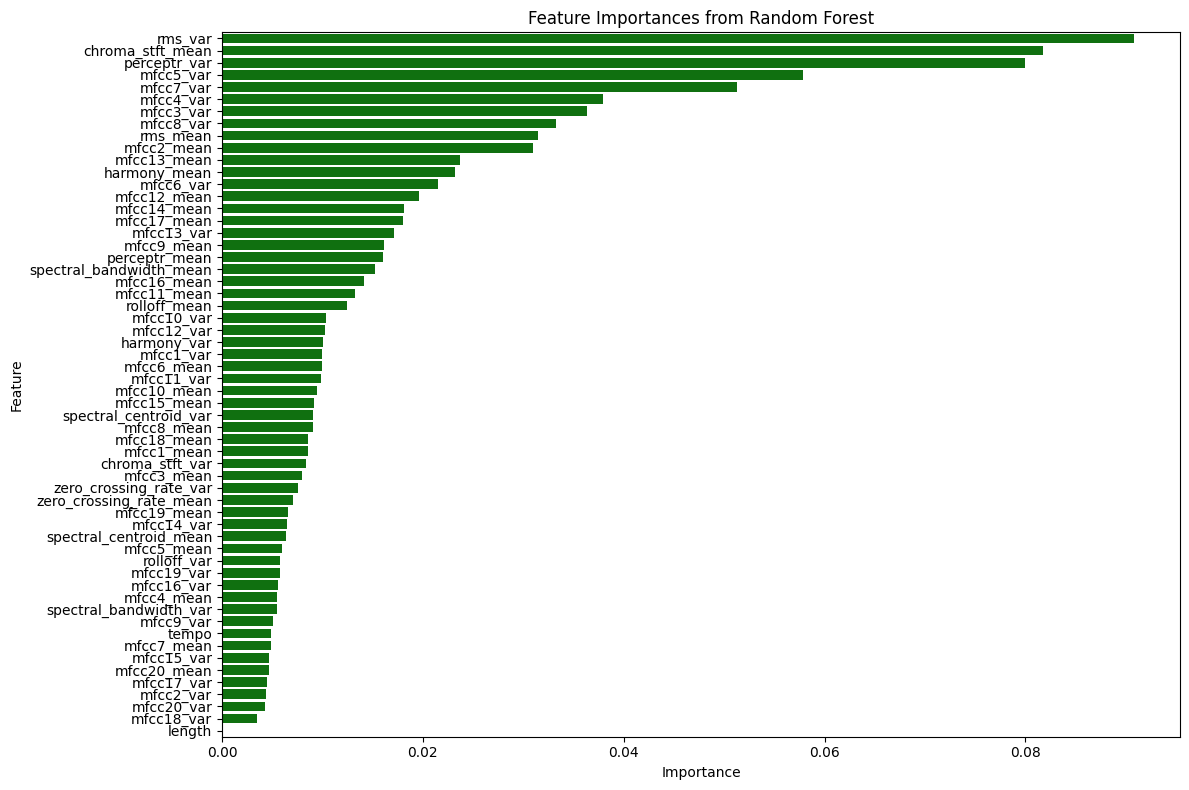

In [ ]:
# Genre Classification - Random Forest
# ------------------------------------
# Train and evaluate a Random Forest classifier for music genre classification (rock vs hip-hop).
# This provides an alternative to XGBoost and allows comparison of model performance.

from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model on scaled training data
rf_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate performance
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest (Rock vs Hip-Hop)")
plt.tight_layout()
plt.show()

# Feature Importances from Random Forest
rf_importances = rf_model.feature_importances_
features = X.columns
indices_rf = np.argsort(rf_importances)[::-1]

plt.figure(figsize=(12, 8))
sns.barplot(x=rf_importances[indices_rf], y=features[indices_rf], color='green')
plt.title("Feature Importances from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

XGBoost Accuracy: 96.50%
Random Forest Accuracy: 96.50%

XGBoost Classification Report:
              precision    recall  f1-score   support

      hiphop       0.95      0.97      0.96       193
        rock       0.98      0.96      0.97       207

    accuracy                           0.96       400
   macro avg       0.96      0.97      0.96       400
weighted avg       0.97      0.96      0.97       400


Random Forest Classification Report:
              precision    recall  f1-score   support

      hiphop       0.96      0.97      0.96       193
        rock       0.97      0.96      0.97       207

    accuracy                           0.96       400
   macro avg       0.96      0.97      0.96       400
weighted avg       0.97      0.96      0.97       400



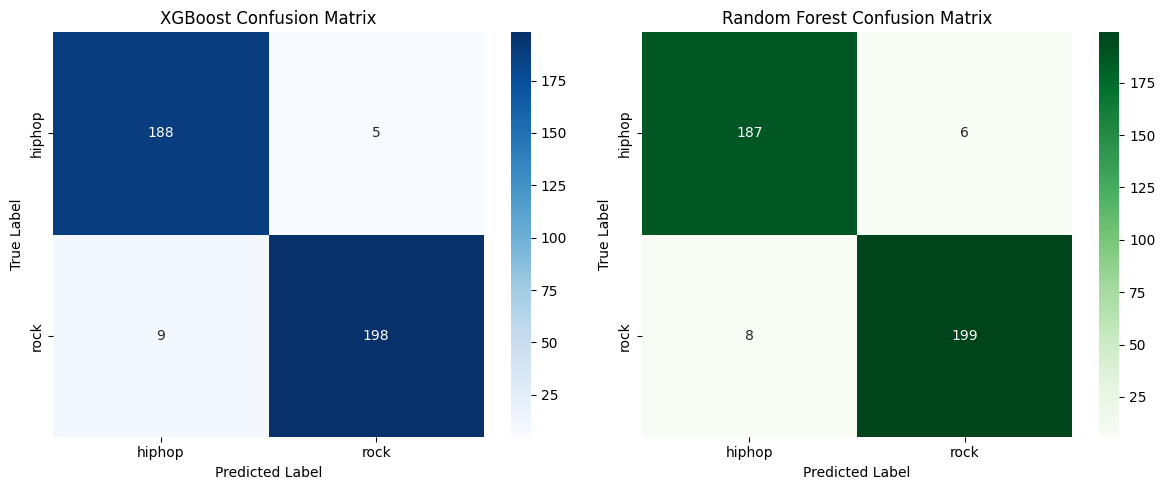

In [ ]:
# Compare XGBoost and Random Forest Models
"""
This cell compares the performance of XGBoost and Random Forest classifiers on the test set.
It displays their accuracy, confusion matrices, and classification reports side by side for easy analysis.
"""

# Accuracy comparison
print(f"XGBoost Accuracy: {accuracy * 100:.2f}%")
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

# Classification report comparison
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

# Confusion matrix comparison
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axs[0])
axs[0].set_title('XGBoost Confusion Matrix')
axs[0].set_xlabel('Predicted Label')
axs[0].set_ylabel('True Label')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axs[1])
axs[1].set_title('Random Forest Confusion Matrix')
axs[1].set_xlabel('Predicted Label')
axs[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [ ]:
# Additional Model Comparisons: Logistic Regression, SVM, KNN, Extra Trees, MLP
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'MLP': MLPClassifier(max_iter=1000, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_model = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_model)
    print(f"{name} Accuracy: {acc * 100:.2f}%")
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred_model, target_names=label_encoder.classes_))
    print("-"*50)


### KNN - Music Recommendation

The **K-Nearest Neighbors (KNN)** algorithm is used to build a music recommendation system based on audio feature similarity.

**How KNN Works for Music:**

- Each song is represented by a feature vector extracted from its audio (e.g., MFCCs, spectral features).
- KNN finds the 'k' most similar songs to a given input song by measuring the distance between feature vectors.
- Instead of Euclidean distance, we use **Cosine distance** to better capture relationships in high-dimensional feature space.

**Why Use Cosine Distance?**

- Cosine distance focuses on the angle between vectors, making it robust to differences in magnitude and better suited for audio features.

**Workflow:**

1. Extract and scale feature vectors for all songs.
2. Fit the KNN model using cosine distance.
3. For a given song, recommend the top 'k' most similar tracks based on feature similarity.

KNN-based recommendation helps users discover songs with similar audio characteristics, enhancing music exploration and playlist generation.

In [ ]:
# Filter song paths for only hiphop and rock
song_paths = []
for genre in ['rock', 'hiphop']:
    genre_path = os.path.join(dataset_path, genre)
    if os.path.isdir(genre_path):
        files = os.listdir(genre_path)
        for file_name in files:
            file_path = os.path.join(genre_path, file_name)
            if os.path.isfile(file_path):
                print(f"Adding song path: {file_path}")  # Print the song path
                song_paths.append(file_path)


Adding song path: Data/genres_original/rock/rock.00014.wav
Adding song path: Data/genres_original/rock/rock.00006.wav
Adding song path: Data/genres_original/rock/rock.00067.wav
Adding song path: Data/genres_original/rock/rock.00030.wav
Adding song path: Data/genres_original/rock/rock.00082.wav
Adding song path: Data/genres_original/rock/rock.00001.wav
Adding song path: Data/genres_original/rock/rock.00010.wav
Adding song path: Data/genres_original/rock/rock.00017.wav
Adding song path: Data/genres_original/rock/rock.00002.wav
Adding song path: Data/genres_original/rock/rock.00007.wav
Adding song path: Data/genres_original/rock/rock.00011.wav
Adding song path: Data/genres_original/rock/rock.00032.wav
Adding song path: Data/genres_original/rock/rock.00025.wav
Adding song path: Data/genres_original/rock/rock.00023.wav
Adding song path: Data/genres_original/rock/rock.00092.wav
Adding song path: Data/genres_original/rock/rock.00016.wav
Adding song path: Data/genres_original/rock/rock.00077.w

In [ ]:
# Scale full dataset features
features_array = data.drop(columns=["filename", "label"])
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_array)

In [ ]:

# Model - KNN with Cosine Distance
nn_model = NearestNeighbors(n_neighbors=5, metric='cosine')
nn_model.fit(features_scaled)

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None



🎵 Input Song:
Data/genres_original/rock/rock.00014.wav

🔁 Recommended Similar Songs:
Data/genres_original/rock/rock.00006.wav - Similarity: 97.86%
Data/genres_original/rock/rock.00067.wav - Similarity: 91.50%
Data/genres_original/rock/rock.00001.wav - Similarity: 86.32%
Data/genres_original/rock/rock.00010.wav - Similarity: 86.30%


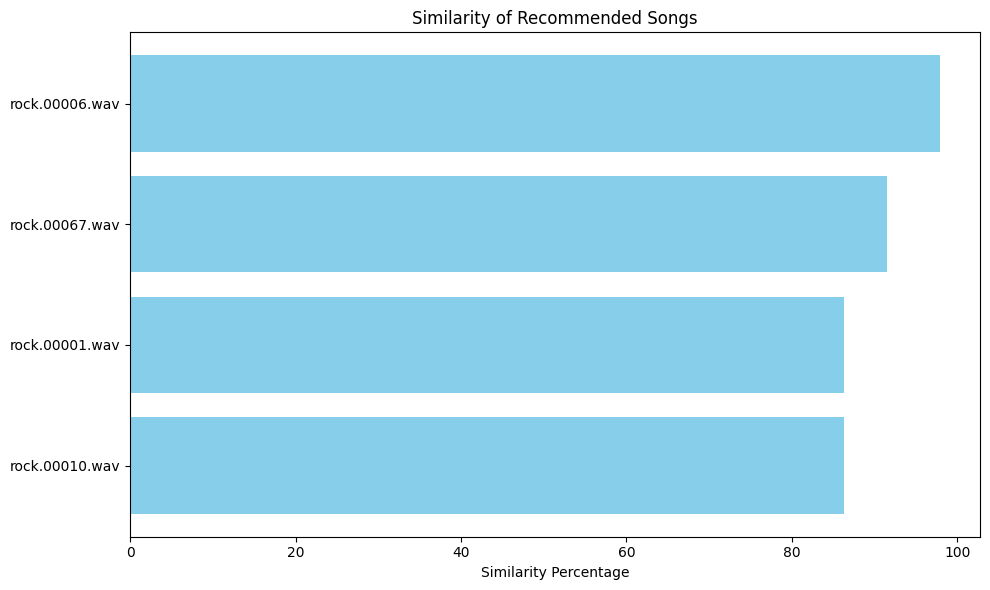

In [ ]:
# Recommendation
def recommend_songs(song_index, model, features_scaled, song_paths, num_recommendations=5):
    distances, indices = model.kneighbors([features_scaled[song_index]])
    recommended_indices = indices[0][1:num_recommendations+1]
    recommended_distances = distances[0][1:num_recommendations+1]
    similarity_percentages = (1 - recommended_distances) * 100
    return recommended_indices, similarity_percentages


# Run a test recommendation
test_index = 0
rec_indices, sim_scores = recommend_songs(
    song_index=test_index,
    model=nn_model,
    features_scaled=features_scaled,
    song_paths=song_paths,
    num_recommendations=5
)


print("\n🎵 Input Song:")
print(song_paths[test_index])
print("\n🔁 Recommended Similar Songs:")
for idx, sim in zip(rec_indices, sim_scores):
    print(f"{song_paths[idx]} - Similarity: {sim:.2f}%")


# Plot recommendations
plt.figure(figsize=(10, 6))
recommended_song_names = [os.path.basename(song_paths[i]) for i in rec_indices]
plt.barh(recommended_song_names, sim_scores, color='skyblue')
plt.xlabel("Similarity Percentage")
plt.title("Similarity of Recommended Songs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

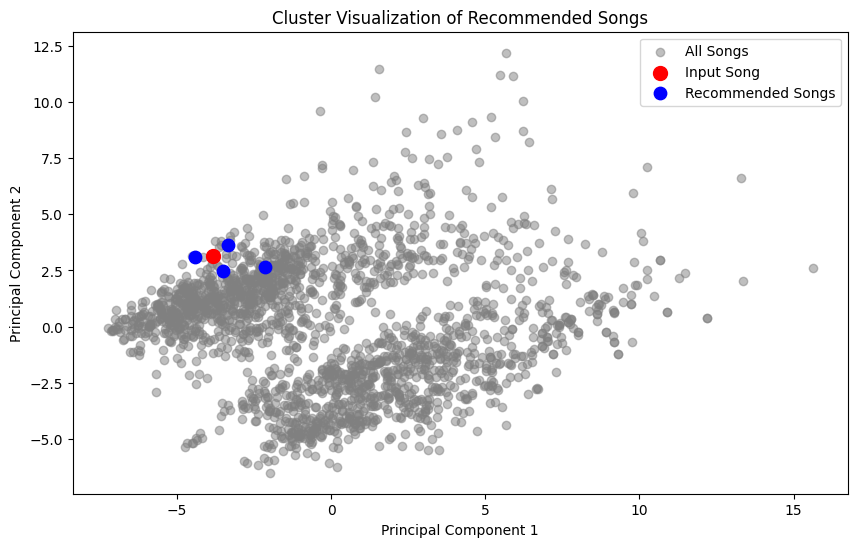

In [ ]:
# Reduce feature dimensions to 2 using PCA for visualization.
# Plot all songs, the input song, and its recommended songs in the 2D PCA space to show their clustering and similarity.
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

nn_model = NearestNeighbors(n_neighbors=6, metric='cosine')
nn_model.fit(features_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(features_pca[:, 0], features_pca[:, 1], c='gray', alpha=0.5, label='All Songs')
plt.scatter(features_pca[test_index, 0], features_pca[test_index, 1], c='red', label='Input Song', s=100)
plt.scatter(features_pca[rec_indices, 0], features_pca[rec_indices, 1], c='blue', label='Recommended Songs', s=80)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Cluster Visualization of Recommended Songs")
plt.legend()
plt.show()

In [ ]:
print("Input Song Preview:")
input_song_path = song_paths[test_index]
input_audio, sr = librosa.load(input_song_path, sr=None, duration=5)
display(Audio(data=input_audio, rate=sr))

print("\nRecommended Songs Previews:\n")
for i, rec_idx in enumerate(rec_indices):
    rec_song_path = song_paths[rec_idx]
    rec_audio, sr = librosa.load(rec_song_path, sr=None, duration=5)
    print(f"Recommendation {i+1}: {os.path.basename(rec_song_path)}")
    display(Audio(data=rec_audio, rate=sr))

Input Song Preview:



Recommended Songs Previews:

Recommendation 1: rock.00006.wav


Recommendation 2: rock.00067.wav


Recommendation 3: rock.00001.wav


Recommendation 4: rock.00010.wav
